In [1]:
# !python3 -m pip install --upgrade pip

In [2]:
!pip install insightface opencv-python numpy onnxruntime

  Using cached insightface-0.7.3.tar.gz (439 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached onnx-1.19.1-cp39-cp39-win_amd64.whl.metadata (7.2 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata (11 kB)
  Using cached pillow-11.3.0-cp39-cp39-win_amd64.whl.metadata (9.2 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl.metadata (15 kB)
  Using cached scikit_image-0.24.0-cp39-cp39-win_amd64.whl.metadata (14 kB)
  Using cached easydict-1.13-py3-none-any.whl.metadata (4.2 k

In [3]:
!pip install opencv-python

In [4]:
!pip install onnxruntime

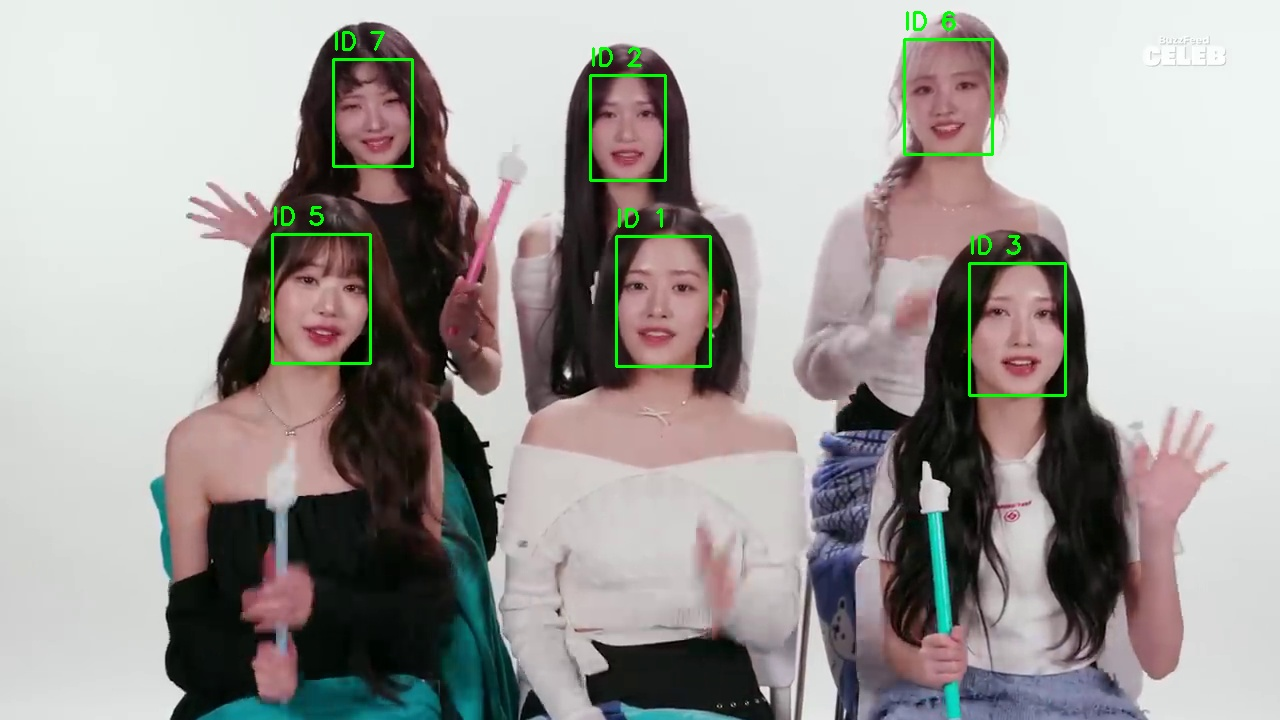

KeyboardInterrupt: 

In [12]:
from IPython.display import display, Image, clear_output
import cv2
import numpy as np
from insightface.app import FaceAnalysis
import time

VIDEO_PATH = "IVE.mp4"
SIM_THRESHOLD = 0.5
FONT = cv2.FONT_HERSHEY_SIMPLEX

app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=-1, det_size=(640, 640))  # -1 = CPU (ปลอดภัยใน Jupyter)

known_embeddings = []
known_ids = []
next_id = 1

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

cap = cv2.VideoCapture(VIDEO_PATH)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    faces = app.get(frame)

    for face in faces:
        emb = face.embedding
        assigned_id = None
        best_sim = 0

        for i, known_emb in enumerate(known_embeddings):
            sim = cosine_similarity(emb, known_emb)
            if sim > best_sim:
                best_sim = sim
                assigned_id = known_ids[i]

        if best_sim < SIM_THRESHOLD:
            assigned_id = next_id
            known_embeddings.append(emb)
            known_ids.append(next_id)
            next_id += 1

        x1, y1, x2, y2 = map(int, face.bbox)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(frame, f"ID {assigned_id}", (x1, y1 - 10),
                    FONT, 0.8, (0,255,0), 2)

    # 🔥 แทน cv2.imshow
    clear_output(wait=True)
    _, buffer = cv2.imencode(".jpg", frame)
    display(Image(data=buffer.tobytes()))

    # time.sleep(0.02)  # คุม FPS

cap.release()
print("Done")
